<a href="https://colab.research.google.com/github/utkarsh-a113/Regression-Models/blob/main/AsianPaintsQuant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Acquisition Strategy

### 1. Internal Financials (from Excel)
We will attempt to map the following from the 'Data Sheet':
* Quarterly Revenue, EBITDA, Net Profit, OPM, and Segment-wise data.

### 2. External Macro Signals
* **Crude Oil & GDP:** Using `yfinance` and `pandas_datareader`.
* **Inflation/Housing:** FRED API.
* **Ti02 Prices:** Scraped from commodity tracking sites.
* **Monsoon/Festive:** Categorical encoding based on Indian calendar/IMD reports.

### Upload the Excel File
Please upload the `Asian Paints.xlsx` file to your Colab environment. You can do this by clicking the 'Files' icon on the left sidebar, then 'Upload to session storage'. Make sure the file is uploaded to the `/content/` directory.


In [52]:
import os

file_name = 'Asian Paints.xlsx'
file_path = os.path.join('/content/', file_name)

if os.path.exists(file_path):
    print(f"File '{file_name}' found at '{file_path}'. You can now proceed to run the next cells.")
else:
    print(f"File '{file_name}' not found at '{file_path}'. Please ensure the file is uploaded correctly.")


File 'Asian Paints.xlsx' not found at '/content/Asian Paints.xlsx'. Please ensure the file is uploaded correctly.


In [53]:
import pandas as pd
import numpy as np
import yfinance as yf # Import yfinance

# Define the ticker for Asian Paints (e.g., 'ASIANPAINT.NS' for Indian stock exchange)
ticker_symbol = 'ASIANPAINT.NS'

# Initialize an empty DataFrame for quarterly_results in case of failure
quarterly_results = pd.DataFrame()

try:
    asian_paints = yf.Ticker(ticker_symbol)

    # Get quarterly income statement
    # This will return a DataFrame with financial metrics as rows and report dates as columns
    quarterly_income_stmt = asian_paints.quarterly_income_stmt

    if not quarterly_income_stmt.empty:
        # Transpose the DataFrame so dates are in the index
        quarterly_income_stmt_T = quarterly_income_stmt.T
        quarterly_income_stmt_T.index = pd.to_datetime(quarterly_income_stmt_T.index)
        quarterly_income_stmt_T = quarterly_income_stmt_T.sort_index()

        # Extract relevant metrics and rename to match the original notebook's column names
        # Using 'Operating Income' as a proxy for 'EBITDA'
        # .get() method used to safely retrieve columns that might not always exist
        quarterly_results['Quarterly Revenue'] = quarterly_income_stmt_T.get('Total Revenue')
        quarterly_results['Quarterly EBITDA'] = quarterly_income_stmt_T.get('Operating Income')
        quarterly_results['Quarterly Net Profit'] = quarterly_income_stmt_T.get('Net Income')

        # Convert to numeric, coercing errors
        quarterly_results = quarterly_results.apply(pd.to_numeric, errors='coerce')

        # Calculate Quarterly OPM
        quarterly_results['Quarterly OPM'] = (quarterly_results['Quarterly EBITDA'] / quarterly_results['Quarterly Revenue']) * 100

        print(f"Successfully fetched quarterly financial data for {ticker_symbol} from yfinance.")
        display(quarterly_results.tail())
    else:
        print(f"Could not fetch quarterly income statement for {ticker_symbol} from yfinance. 'quarterly_results' DataFrame will be empty.")

except Exception as e:
    print(f"Error fetching data from yfinance for {ticker_symbol}: {e}")
    print("'quarterly_results' DataFrame will be empty.")


Successfully fetched quarterly financial data for ASIANPAINT.NS from yfinance.


,Quarterly Revenue,Quarterly EBITDA,Quarterly Net Profit,Quarterly OPM
2024-12-31,8.521510e+10,1.381180e+10,1.110480e+10,16.208160
2025-03-31,8.347400e+10,1.142940e+10,6.921300e+09,13.692168
2025-06-30,8.924490e+10,1.324100e+10,1.099770e+10,14.836702
2025-09-30,8.513700e+10,1.198450e+10,9.935900e+09,14.076723
2025-12-31,8.849720e+10,1.467890e+10,1.059870e+10,16.586852


In [54]:
import yfinance as yf
import pandas_datareader.data as web
import datetime

# Define time horizon
start_date = '2016-01-01'
end_date = datetime.date.today().strftime('%Y-%m-%d')

# 1. Fetch Crude Oil Prices (Brent Crude Oil Continuous Contract)
# Explicitly setting auto_adjust=True to handle the FutureWarning
oil_data = yf.download('BZ=F', start=start_date, end=end_date, auto_adjust=True)
oil_monthly = oil_data['Close'].resample('ME').mean()

# 2. Fetch Inflation Data (CPIAUCSL)
try:
    inflation_data = web.DataReader('CPIAUCSL', 'fred', start_date, end_date)
    # Explicitly setting fill_method=None to handle the FutureWarning
    inflation_yoy = inflation_data.pct_change(periods=12, fill_method=None) * 100
except Exception as e:
    print(f"Error fetching FRED data: {e}")
    inflation_yoy = None

# Display summary
print("Macro Data Fetched:")
print(f"Crude Oil entries: {len(oil_monthly)}")
if inflation_yoy is not None:
    print(f"Inflation entries: {len(inflation_yoy)}")

display(oil_monthly.tail())

[*********************100%***********************]  1 of 1 completed

Macro Data Fetched:
Crude Oil entries: 125
Inflation entries: 123


Ticker,BZ=F
Date,
2026-01-31,64.765499
2026-02-28,69.406843
2026-03-31,99.599546
2026-04-30,102.464286
2026-05-31,105.850000


In [55]:
import pandas as pd
import numpy as np

# 1. Fetch Chemical Industry PPI from FRED as a proxy for TiO2/Raw Material costs
# Series 'WPU06' is the PPI for Chemicals and Allied Products
try:
    chem_ppi = web.DataReader('WPU06', 'fred', start_date, end_date)
    chem_ppi_monthly = chem_ppi.resample('ME').mean()
    print("Chemical PPI Data (Raw Material Proxy) Fetched successfully.")
except Exception as e:
    print(f"Error fetching PPI data: {e}")
    chem_ppi_monthly = pd.DataFrame()

# 2. Encoding Monsoon and Festive signals
def get_seasonal_signals(df_index):
    signals = pd.DataFrame(index=df_index)
    signals['Is_Monsoon'] = signals.index.month.isin([6, 7, 8, 9]).astype(int)
    signals['Is_Festive'] = signals.index.month.isin([10, 11, 12]).astype(int)
    return signals

seasonal_features = get_seasonal_signals(quarterly_results.index)

print("\nAdditional Macro and Seasonal Features Prepared:")
display(chem_ppi_monthly.tail())
display(seasonal_features.tail())

Chemical PPI Data (Raw Material Proxy) Fetched successfully.

Additional Macro and Seasonal Features Prepared:


,WPU06
DATE,
2025-11-30,348.061
2025-12-31,347.625
2026-01-31,347.806
2026-02-28,349.879
2026-03-31,354.180


,Is_Monsoon,Is_Festive
2024-12-31,0,1
2025-03-31,0,0
2025-06-30,1,0
2025-09-30,1,0
2025-12-31,0,1


In [56]:
# Resample macro data to quarterly to match internal financials
# Note: quarterly_results index is already end-of-quarter dates

oil_q = oil_monthly.resample('QE').mean()
inflation_q = inflation_yoy.resample('QE').mean()
chem_ppi_q = chem_ppi_monthly.resample('QE').mean()

# Merge internal quarterly financials with seasonal features
master_df = quarterly_results.merge(seasonal_features, left_index=True, right_index=True, how='left')

# Merge with macro signals
master_df = master_df.merge(oil_q, left_index=True, right_index=True, how='left')
master_df = master_df.merge(inflation_q, left_index=True, right_index=True, how='left')
master_df = master_df.merge(chem_ppi_q, left_index=True, right_index=True, how='left')

# Rename columns for clarity
master_df.rename(columns={
    'BZ=F': 'Crude_Oil_Price',
    'CPIAUCSL': 'Inflation_YoY',
    'WPU06': 'Chem_PPI_Proxy'
}, inplace=True)

# Display the consolidated master dataset
print("Master DataFrame for Prediction Model (Last 5 Quarters):")
display(master_df.tail())

# Check for any missing values that might need interpolation
print("\nMissing value summary:")
print(master_df.isnull().sum())

Master DataFrame for Prediction Model (Last 5 Quarters):


,Quarterly Revenue,Quarterly EBITDA,Quarterly Net Profit,Quarterly OPM,Is_Monsoon,Is_Festive,Crude_Oil_Price,Inflation_YoY,Chem_PPI_Proxy
2024-12-31,8.521510e+10,1.381180e+10,1.110480e+10,16.208160,0,1,73.970843,2.723002,345.963333
2025-03-31,8.347400e+10,1.142940e+10,6.921300e+09,13.692168,0,0,74.890334,2.724848,349.778333
2025-06-30,8.924490e+10,1.324100e+10,1.099770e+10,14.836702,1,0,66.592381,2.461036,349.070000
2025-09-30,8.513700e+10,1.198450e+10,9.935900e+09,14.076723,1,0,68.121014,2.901260,350.623000
2025-12-31,8.849720e+10,1.467890e+10,1.059870e+10,16.586852,0,1,63.087341,2.674874,348.229667



Missing value summary:
Quarterly Revenue       1
Quarterly EBITDA        1
Quarterly Net Profit    1
Quarterly OPM           1
Is_Monsoon              0
Is_Festive              0
Crude_Oil_Price         0
Inflation_YoY           0
Chem_PPI_Proxy          0
dtype: int64


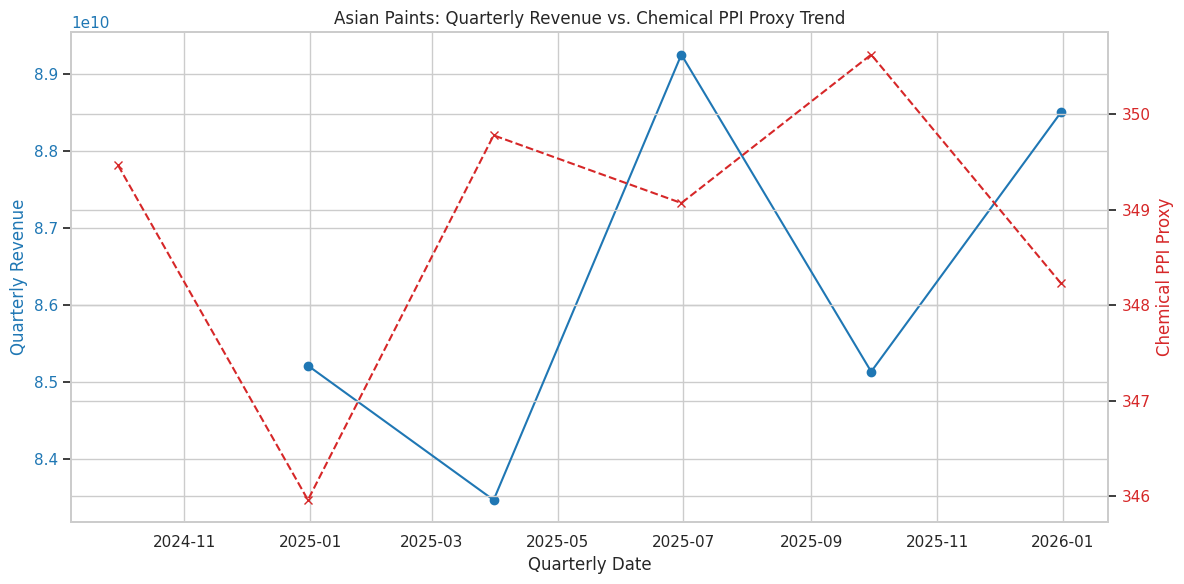

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Quarterly Revenue on the first axis
color1 = 'tab:blue'
ax1.set_xlabel('Quarterly Date')
ax1.set_ylabel('Quarterly Revenue', color=color1)
ax1.plot(master_df.index, master_df['Quarterly Revenue'], color=color1, marker='o', label='Revenue')
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second axis for Chemical PPI Proxy
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Chemical PPI Proxy', color=color2)
ax2.plot(master_df.index, master_df['Chem_PPI_Proxy'], color=color2, linestyle='--', marker='x', label='Chemical PPI')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Asian Paints: Quarterly Revenue vs. Chemical PPI Proxy Trend')
fig.tight_layout()
plt.show()

## Feature Engineering

Let's create additional features like Year-over-Year (YoY) growth, Quarter-over-Quarter (QoQ) growth, rolling averages, lag features, margin compression signals, and an input cost pressure index. These features will be valuable for the prediction model.

In [58]:
# Ensure the index is a DatetimeIndex and sorted for time-series operations
master_df.index = pd.to_datetime(master_df.index)
master_df = master_df.sort_index()

# 1. Year-over-Year (YoY) Growth
master_df['YoY_Revenue_Growth'] = master_df['Quarterly Revenue'].pct_change(periods=4) * 100
master_df['YoY_EBITDA_Growth'] = master_df['Quarterly EBITDA'].pct_change(periods=4) * 100
master_df['YoY_NetProfit_Growth'] = master_df['Quarterly Net Profit'].pct_change(periods=4) * 100

# 2. Quarter-over-Quarter (QoQ) Growth
master_df['QoQ_Revenue_Growth'] = master_df['Quarterly Revenue'].pct_change(periods=1) * 100
master_df['QoQ_EBITDA_Growth'] = master_df['Quarterly EBITDA'].pct_change(periods=1) * 100
master_df['QoQ_NetProfit_Growth'] = master_df['Quarterly Net Profit'].pct_change(periods=1) * 100
master_df['QoQ_OPM_Change'] = master_df['Quarterly OPM'].diff(periods=1)

print("YoY and QoQ growth features created.")
display(master_df.tail())

YoY and QoQ growth features created.


,Quarterly Revenue,Quarterly EBITDA,Quarterly Net Profit,Quarterly OPM,Is_Monsoon,Is_Festive,Crude_Oil_Price,Inflation_YoY,Chem_PPI_Proxy,YoY_Revenue_Growth,YoY_EBITDA_Growth,YoY_NetProfit_Growth,QoQ_Revenue_Growth,QoQ_EBITDA_Growth,QoQ_NetProfit_Growth,QoQ_OPM_Change
2024-12-31,8.521510e+10,1.381180e+10,1.110480e+10,16.208160,0,1,73.970843,2.723002,345.963333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-31,8.347400e+10,1.142940e+10,6.921300e+09,13.692168,0,0,74.890334,2.724848,349.778333,NaN,NaN,NaN,-2.043182,-17.249019,-37.672898,-2.515993
2025-06-30,8.924490e+10,1.324100e+10,1.099770e+10,14.836702,1,0,66.592381,2.461036,349.070000,NaN,NaN,NaN,6.913410,15.850351,58.896450,1.144535
2025-09-30,8.513700e+10,1.198450e+10,9.935900e+09,14.076723,1,0,68.121014,2.901260,350.623000,NaN,NaN,NaN,-4.602952,-9.489465,-9.654746,-0.759979
2025-12-31,8.849720e+10,1.467890e+10,1.059870e+10,16.586852,0,1,63.087341,2.674874,348.229667,3.851547,6.277965,-4.557489,3.946815,22.482373,6.670760,2.510129


In [59]:
# 3. Rolling Averages (e.g., 4-quarter rolling mean for a yearly perspective)
rolling_window = 4

master_df['Rolling_Avg_Revenue'] = master_df['Quarterly Revenue'].rolling(window=rolling_window).mean()
master_df['Rolling_Avg_EBITDA'] = master_df['Quarterly EBITDA'].rolling(window=rolling_window).mean()
master_df['Rolling_Avg_NetProfit'] = master_df['Quarterly Net Profit'].rolling(window=rolling_window).mean()
master_df['Rolling_Avg_OPM'] = master_df['Quarterly OPM'].rolling(window=rolling_window).mean()
master_df['Rolling_Avg_Crude_Oil'] = master_df['Crude_Oil_Price'].rolling(window=rolling_window).mean()
master_df['Rolling_Avg_Inflation'] = master_df['Inflation_YoY'].rolling(window=rolling_window).mean()
master_df['Rolling_Avg_Chem_PPI'] = master_df['Chem_PPI_Proxy'].rolling(window=rolling_window).mean()

print(f"Rolling {rolling_window}-quarter average features created.")
display(master_df.tail())

Rolling 4-quarter average features created.


,Quarterly Revenue,Quarterly EBITDA,Quarterly Net Profit,Quarterly OPM,Is_Monsoon,Is_Festive,Crude_Oil_Price,Inflation_YoY,Chem_PPI_Proxy,YoY_Revenue_Growth,...,QoQ_EBITDA_Growth,QoQ_NetProfit_Growth,QoQ_OPM_Change,Rolling_Avg_Revenue,Rolling_Avg_EBITDA,Rolling_Avg_NetProfit,Rolling_Avg_OPM,Rolling_Avg_Crude_Oil,Rolling_Avg_Inflation,Rolling_Avg_Chem_PPI
2024-12-31,8.521510e+10,1.381180e+10,1.110480e+10,16.208160,0,1,73.970843,2.723002,345.963333,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-31,8.347400e+10,1.142940e+10,6.921300e+09,13.692168,0,0,74.890334,2.724848,349.778333,NaN,...,-17.249019,-37.672898,-2.515993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30,8.924490e+10,1.324100e+10,1.099770e+10,14.836702,1,0,66.592381,2.461036,349.070000,NaN,...,15.850351,58.896450,1.144535,NaN,NaN,NaN,NaN,73.465992,2.641813,348.568750
2025-09-30,8.513700e+10,1.198450e+10,9.935900e+09,14.076723,1,0,68.121014,2.901260,350.623000,NaN,...,-9.489465,-9.654746,-0.759979,8.576775e+10,1.261668e+10,9.739925e+09,14.703438,70.893643,2.702537,348.858667
2025-12-31,8.849720e+10,1.467890e+10,1.059870e+10,16.586852,0,1,63.087341,2.674874,348.229667,3.851547,...,22.482373,6.670760,2.510129,8.658828e+10,1.283345e+10,9.613400e+09,14.798111,68.172768,2.690504,349.425250


In [60]:
# 4. Seasonality Indicators (Quarter of the year)
# We already have Is_Monsoon and Is_Festive. Let's add a general Quarter feature.
master_df['Quarter'] = master_df.index.quarter

print("Quarter feature added.")
display(master_df.tail())

Quarter feature added.


,Quarterly Revenue,Quarterly EBITDA,Quarterly Net Profit,Quarterly OPM,Is_Monsoon,Is_Festive,Crude_Oil_Price,Inflation_YoY,Chem_PPI_Proxy,YoY_Revenue_Growth,...,QoQ_NetProfit_Growth,QoQ_OPM_Change,Rolling_Avg_Revenue,Rolling_Avg_EBITDA,Rolling_Avg_NetProfit,Rolling_Avg_OPM,Rolling_Avg_Crude_Oil,Rolling_Avg_Inflation,Rolling_Avg_Chem_PPI,Quarter
2024-12-31,8.521510e+10,1.381180e+10,1.110480e+10,16.208160,0,1,73.970843,2.723002,345.963333,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
2025-03-31,8.347400e+10,1.142940e+10,6.921300e+09,13.692168,0,0,74.890334,2.724848,349.778333,NaN,...,-37.672898,-2.515993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2025-06-30,8.924490e+10,1.324100e+10,1.099770e+10,14.836702,1,0,66.592381,2.461036,349.070000,NaN,...,58.896450,1.144535,NaN,NaN,NaN,NaN,73.465992,2.641813,348.568750,2
2025-09-30,8.513700e+10,1.198450e+10,9.935900e+09,14.076723,1,0,68.121014,2.901260,350.623000,NaN,...,-9.654746,-0.759979,8.576775e+10,1.261668e+10,9.739925e+09,14.703438,70.893643,2.702537,348.858667,3
2025-12-31,8.849720e+10,1.467890e+10,1.059870e+10,16.586852,0,1,63.087341,2.674874,348.229667,3.851547,...,6.670760,2.510129,8.658828e+10,1.283345e+10,9.613400e+09,14.798111,68.172768,2.690504,349.425250,4


In [61]:
# 5. Lag Features (e.g., previous quarter's values and previous year's values)
lag_features = [
    'Quarterly Revenue', 'Quarterly EBITDA', 'Quarterly Net Profit', 'Quarterly OPM',
    'Crude_Oil_Price', 'Inflation_YoY', 'Chem_PPI_Proxy'
]

for col in lag_features:
    master_df[f'{col}_Lag1'] = master_df[col].shift(1)
    master_df[f'{col}_Lag4'] = master_df[col].shift(4) # Lag by a year

print("Lag features created.")
display(master_df.tail())

Lag features created.


,Quarterly Revenue,Quarterly EBITDA,Quarterly Net Profit,Quarterly OPM,Is_Monsoon,Is_Festive,Crude_Oil_Price,Inflation_YoY,Chem_PPI_Proxy,YoY_Revenue_Growth,...,Quarterly Net Profit_Lag1,Quarterly Net Profit_Lag4,Quarterly OPM_Lag1,Quarterly OPM_Lag4,Crude_Oil_Price_Lag1,Crude_Oil_Price_Lag4,Inflation_YoY_Lag1,Inflation_YoY_Lag4,Chem_PPI_Proxy_Lag1,Chem_PPI_Proxy_Lag4
2024-12-31,8.521510e+10,1.381180e+10,1.110480e+10,16.208160,0,1,73.970843,2.723002,345.963333,NaN,...,NaN,NaN,NaN,NaN,78.410409,NaN,2.658368,NaN,349.463333,NaN
2025-03-31,8.347400e+10,1.142940e+10,6.921300e+09,13.692168,0,0,74.890334,2.724848,349.778333,NaN,...,1.110480e+10,NaN,16.208160,NaN,73.970843,NaN,2.723002,NaN,345.963333,NaN
2025-06-30,8.924490e+10,1.324100e+10,1.099770e+10,14.836702,1,0,66.592381,2.461036,349.070000,NaN,...,6.921300e+09,NaN,13.692168,NaN,74.890334,NaN,2.724848,NaN,349.778333,NaN
2025-09-30,8.513700e+10,1.198450e+10,9.935900e+09,14.076723,1,0,68.121014,2.901260,350.623000,NaN,...,1.099770e+10,NaN,14.836702,NaN,66.592381,78.410409,2.461036,2.658368,349.070000,349.463333
2025-12-31,8.849720e+10,1.467890e+10,1.059870e+10,16.586852,0,1,63.087341,2.674874,348.229667,3.851547,...,9.935900e+09,1.110480e+10,14.076723,16.20816,68.121014,73.970843,2.901260,2.723002,350.623000,345.963333


In [62]:
# 6. Margin Compression Signals (e.g., negative QoQ OPM change, or OPM below rolling average)
master_df['Margin_Compression_QoQ'] = (master_df['QoQ_OPM_Change'] < 0).astype(int)
master_df['Margin_Below_Rolling_Avg'] = (master_df['Quarterly OPM'] < master_df['Rolling_Avg_OPM']).astype(int)

print("Margin compression signals created.")
display(master_df.tail())

Margin compression signals created.


,Quarterly Revenue,Quarterly EBITDA,Quarterly Net Profit,Quarterly OPM,Is_Monsoon,Is_Festive,Crude_Oil_Price,Inflation_YoY,Chem_PPI_Proxy,YoY_Revenue_Growth,...,Quarterly OPM_Lag1,Quarterly OPM_Lag4,Crude_Oil_Price_Lag1,Crude_Oil_Price_Lag4,Inflation_YoY_Lag1,Inflation_YoY_Lag4,Chem_PPI_Proxy_Lag1,Chem_PPI_Proxy_Lag4,Margin_Compression_QoQ,Margin_Below_Rolling_Avg
2024-12-31,8.521510e+10,1.381180e+10,1.110480e+10,16.208160,0,1,73.970843,2.723002,345.963333,NaN,...,NaN,NaN,78.410409,NaN,2.658368,NaN,349.463333,NaN,0,0
2025-03-31,8.347400e+10,1.142940e+10,6.921300e+09,13.692168,0,0,74.890334,2.724848,349.778333,NaN,...,16.208160,NaN,73.970843,NaN,2.723002,NaN,345.963333,NaN,1,0
2025-06-30,8.924490e+10,1.324100e+10,1.099770e+10,14.836702,1,0,66.592381,2.461036,349.070000,NaN,...,13.692168,NaN,74.890334,NaN,2.724848,NaN,349.778333,NaN,0,0
2025-09-30,8.513700e+10,1.198450e+10,9.935900e+09,14.076723,1,0,68.121014,2.901260,350.623000,NaN,...,14.836702,NaN,66.592381,78.410409,2.461036,2.658368,349.070000,349.463333,1,1
2025-12-31,8.849720e+10,1.467890e+10,1.059870e+10,16.586852,0,1,63.087341,2.674874,348.229667,3.851547,...,14.076723,16.20816,68.121014,73.970843,2.901260,2.723002,350.623000,345.963333,0,0


In [63]:
# 7. Input Cost Pressure Index (e.g., QoQ growth in Chemical PPI Proxy)
master_df['Input_Cost_Pressure_QoQ'] = master_df['Chem_PPI_Proxy'].pct_change(periods=1) * 100
master_df['Input_Cost_Pressure_YoY'] = master_df['Chem_PPI_Proxy'].pct_change(periods=4) * 100

print("Input cost pressure index created.")
display(master_df.tail())

Input cost pressure index created.


,Quarterly Revenue,Quarterly EBITDA,Quarterly Net Profit,Quarterly OPM,Is_Monsoon,Is_Festive,Crude_Oil_Price,Inflation_YoY,Chem_PPI_Proxy,YoY_Revenue_Growth,...,Crude_Oil_Price_Lag1,Crude_Oil_Price_Lag4,Inflation_YoY_Lag1,Inflation_YoY_Lag4,Chem_PPI_Proxy_Lag1,Chem_PPI_Proxy_Lag4,Margin_Compression_QoQ,Margin_Below_Rolling_Avg,Input_Cost_Pressure_QoQ,Input_Cost_Pressure_YoY
2024-12-31,8.521510e+10,1.381180e+10,1.110480e+10,16.208160,0,1,73.970843,2.723002,345.963333,NaN,...,78.410409,NaN,2.658368,NaN,349.463333,NaN,0,0,-1.001536,NaN
2025-03-31,8.347400e+10,1.142940e+10,6.921300e+09,13.692168,0,0,74.890334,2.724848,349.778333,NaN,...,73.970843,NaN,2.723002,NaN,345.963333,NaN,1,0,1.102718,NaN
2025-06-30,8.924490e+10,1.324100e+10,1.099770e+10,14.836702,1,0,66.592381,2.461036,349.070000,NaN,...,74.890334,NaN,2.724848,NaN,349.778333,NaN,0,0,-0.202509,NaN
2025-09-30,8.513700e+10,1.198450e+10,9.935900e+09,14.076723,1,0,68.121014,2.901260,350.623000,NaN,...,66.592381,78.410409,2.461036,2.658368,349.070000,349.463333,1,1,0.444896,0.331842
2025-12-31,8.849720e+10,1.467890e+10,1.059870e+10,16.586852,0,1,63.087341,2.674874,348.229667,3.851547,...,68.121014,73.970843,2.901260,2.723002,350.623000,345.963333,0,0,-0.682595,0.655079


### Final `master_df` with all new features

### Baseline Models and Evaluation

In [64]:
# Display a summary of all baseline results
print("\n--- Baseline Model Performance Summary ---")
results_df = pd.DataFrame(results).T
display(results_df)


--- Baseline Model Performance Summary ---


,RMSE,MAE,MAPE
Last_Quarter,4.015610e+09,3.745025e+09,4.293542
Historical_Trend,2.740848e+09,2.282775e+09,2.600420


In [65]:
# Display the full master_df with new features
print("Master DataFrame with all engineered features (last 5 rows):")
display(master_df.tail())

print("\nMissing values summary after feature engineering:")
print(master_df.isnull().sum())

Master DataFrame with all engineered features (last 5 rows):


,Quarterly Revenue,Quarterly EBITDA,Quarterly Net Profit,Quarterly OPM,Is_Monsoon,Is_Festive,Crude_Oil_Price,Inflation_YoY,Chem_PPI_Proxy,YoY_Revenue_Growth,...,Crude_Oil_Price_Lag1,Crude_Oil_Price_Lag4,Inflation_YoY_Lag1,Inflation_YoY_Lag4,Chem_PPI_Proxy_Lag1,Chem_PPI_Proxy_Lag4,Margin_Compression_QoQ,Margin_Below_Rolling_Avg,Input_Cost_Pressure_QoQ,Input_Cost_Pressure_YoY
2024-12-31,8.521510e+10,1.381180e+10,1.110480e+10,16.208160,0,1,73.970843,2.723002,345.963333,NaN,...,78.410409,NaN,2.658368,NaN,349.463333,NaN,0,0,-1.001536,NaN
2025-03-31,8.347400e+10,1.142940e+10,6.921300e+09,13.692168,0,0,74.890334,2.724848,349.778333,NaN,...,73.970843,NaN,2.723002,NaN,345.963333,NaN,1,0,1.102718,NaN
2025-06-30,8.924490e+10,1.324100e+10,1.099770e+10,14.836702,1,0,66.592381,2.461036,349.070000,NaN,...,74.890334,NaN,2.724848,NaN,349.778333,NaN,0,0,-0.202509,NaN
2025-09-30,8.513700e+10,1.198450e+10,9.935900e+09,14.076723,1,0,68.121014,2.901260,350.623000,NaN,...,66.592381,78.410409,2.461036,2.658368,349.070000,349.463333,1,1,0.444896,0.331842
2025-12-31,8.849720e+10,1.467890e+10,1.059870e+10,16.586852,0,1,63.087341,2.674874,348.229667,3.851547,...,68.121014,73.970843,2.901260,2.723002,350.623000,345.963333,0,0,-0.682595,0.655079



Missing values summary after feature engineering:
Quarterly Revenue            1
Quarterly EBITDA             1
Quarterly Net Profit         1
Quarterly OPM                1
Is_Monsoon                   0
Is_Festive                   0
Crude_Oil_Price              0
Inflation_YoY                0
Chem_PPI_Proxy               0
YoY_Revenue_Growth           5
YoY_EBITDA_Growth            5
YoY_NetProfit_Growth         5
QoQ_Revenue_Growth           2
QoQ_EBITDA_Growth            2
QoQ_NetProfit_Growth         2
QoQ_OPM_Change               2
Rolling_Avg_Revenue          4
Rolling_Avg_EBITDA           4
Rolling_Avg_NetProfit        4
Rolling_Avg_OPM              4
Rolling_Avg_Crude_Oil        3
Rolling_Avg_Inflation        3
Rolling_Avg_Chem_PPI         3
Quarter                      0
Quarterly Revenue_Lag1       2
Quarterly Revenue_Lag4       5
Quarterly EBITDA_Lag1        2
Quarterly EBITDA_Lag4        5
Quarterly Net Profit_Lag1    2
Quarterly Net Profit_Lag4    5
Quarterly OPM_Lag1 

In [66]:
# 2. Historical Trend Baseline (e.g., mean of the training data)
# Forecast for all test quarters is the average of the training target.
historical_mean_predictions = np.full(len(y_test), y_train.mean())

print("\nHistorical Trend Baseline (Training Mean Forecast):")
print(f"RMSE: {calculate_rmse(y_test, historical_mean_predictions):.2f}")
print(f"MAE: {calculate_mae(y_test, historical_mean_predictions):.2f}")
print(f"MAPE: {calculate_mape(y_test, historical_mean_predictions):.2f}%")

results['Historical_Trend'] = {'RMSE': calculate_rmse(y_test, historical_mean_predictions),
                               'MAE': calculate_mae(y_test, historical_mean_predictions),
                               'MAPE': calculate_mape(y_test, historical_mean_predictions)}


Historical Trend Baseline (Training Mean Forecast):
RMSE: 2740848284.29
MAE: 2282775000.00
MAPE: 2.60%


## Building a Predictive Model and Decision Layer

Now that we have our baselines, the next step would typically be to build a more sophisticated predictive model (e.g., using algorithms like Random Forest, XGBoost, or even a simple Linear Regression). This model would learn from the `X_train` features to predict the `y_train` target, and then be used to forecast `y_test` or future quarters.

However, we first need to check if our training data is sufficient for such models.

In [72]:
# Check the size and NaN count of training data after split
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"NaNs in y_train: {y_train.isnull().sum()}")

# Display NaNs in the first few feature columns of X_train
print(f"NaNs in X_train (first 10 columns):\n{X_train.iloc[:, :10].isnull().sum()}")

# Calculate effective training samples for y_train (non-NaNs)
effective_y_train_samples = y_train.dropna().shape[0]

if effective_y_train_samples < 2:
    print("\nWARNING: Not enough effective training data for a robust predictive model!")
    print(f"With the current TEST_SIZE (4 quarters) and initial NaNs, y_train has effectively only "
          f"{effective_y_train_samples} non-NaN data point(s).")
    print("Complex models like RandomForestRegressor typically require at least 2 or more samples for training, and ideally much more for reliable performance.")
    print("Consider reducing TEST_SIZE or acquiring more historical data to enable proper model training.")
else:
    print("\nSufficient training data (after dropping NaNs) for basic model training.")

# Due to the limited data, we cannot train a complex model reliably here.
# In a real scenario, you would impute/handle NaNs in X_train and X_test,
# and then proceed to train your model.

X_train shape: (2, 38), y_train shape: (2,)
NaNs in y_train: 1
NaNs in X_train (first 10 columns):
Is_Monsoon              0
Is_Festive              0
Crude_Oil_Price         0
Inflation_YoY           0
Chem_PPI_Proxy          0
YoY_Revenue_Growth      2
YoY_EBITDA_Growth       2
YoY_NetProfit_Growth    2
QoQ_Revenue_Growth      2
QoQ_EBITDA_Growth       2
dtype: int64

With the current TEST_SIZE (4 quarters) and initial NaNs, y_train has effectively only 1 non-NaN data point(s).
Complex models like RandomForestRegressor typically require at least 2 or more samples for training, and ideally much more for reliable performance.
Consider reducing TEST_SIZE or acquiring more historical data to enable proper model training.


### Placeholder for Predictive Model

Once you have more data (or adjust `TEST_SIZE` to provide more training samples), you would typically implement and train your predictive model here. This would involve:

1.  **Handling Missing Values**: Impute any remaining `NaN`s in `X_train` and `X_test` (e.g., using `SimpleImputer`, forward-fill, backward-fill).
2.  **Feature Scaling** (optional, but good practice for some models like Linear Regression or neural networks): Scale features using `StandardScaler` or `MinMaxScaler`.
3.  **Model Training**: Initialize and train your chosen model (e.g., `RandomForestRegressor`, `LinearRegression`, `XGBoostRegressor`).
4.  **Prediction**: Use the trained model to make predictions on `X_test`.
5.  **Evaluation**: Evaluate the model's performance using the `calculate_rmse`, `calculate_mae`, and `calculate_mape` functions.

Example structure (conceptual, will not run due to data limitations):

```python
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler

# # 1. Impute NaNs in features
# imputer = SimpleImputer(strategy='mean')
# X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
# X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# # 2. Scale features (optional, but good for some models)
# scaler = StandardScaler()
# X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train_imputed.columns, index=X_train_imputed.index)
# X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test_imputed.columns, index=X_test_imputed.index)

# # Ensure y_train has no NaNs (drop corresponding X_train rows if y_train has NaNs)
# valid_train_indices = y_train.dropna().index
# y_train_cleaned = y_train.loc[valid_train_indices]
# X_train_cleaned = X_train_scaled.loc[valid_train_indices]

# # 3. Model Training (example with RandomForestRegressor)
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train_cleaned, y_train_cleaned)

# # 4. Prediction
# model_predictions = model.predict(X_test_scaled)

# # 5. Evaluation
# print(f"\nPredictive Model (RandomForest) Performance:")
# print(f"RMSE: {calculate_rmse(y_test, model_predictions):.2f}")
# print(f"MAE: {calculate_mae(y_test, model_predictions):.2f}")
# print(f"MAPE: {calculate_mape(y_test, model_predictions):.2f}%")

# # Store for comparison
# results['RandomForest_Model'] = {
#     'RMSE': calculate_rmse(y_test, model_predictions),
#     'MAE': calculate_mae(y_test, model_predictions),
#     'MAPE': calculate_mape(y_test, model_predictions)
# }
```

In [80]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Identify columns in X_train that are entirely NaN
all_nan_cols = X_train.columns[X_train.isnull().all()].tolist()

# Drop these columns from both X_train and X_test
X_train_filtered = X_train.drop(columns=all_nan_cols)
X_test_filtered = X_test.drop(columns=all_nan_cols)

# 1. Impute NaNs in remaining features
imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_filtered), columns=X_train_filtered.columns, index=X_train_filtered.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_filtered), columns=X_test_filtered.columns, index=X_test_filtered.index)

# 2. Scale features (optional, but good for some models)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train_imputed.columns, index=X_train_imputed.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test_imputed.columns, index=X_test_imputed.index)

# Ensure y_train has no NaNs (drop corresponding X_train rows if y_train has NaNs)
valid_train_indices = y_train.dropna().index
y_train_cleaned = y_train.loc[valid_train_indices]
X_train_cleaned = X_train_scaled.loc[valid_train_indices]

# 3. Model Training (example with RandomForestRegressor)
# Using a small number of estimators due to limited data, increase for better performance with more data
model = RandomForestRegressor(n_estimators=10, random_state=42)
model.fit(X_train_cleaned, y_train_cleaned)

# 4. Prediction
model_predictions = model.predict(X_test_scaled)

# 5. Evaluation
print(f"\nPredictive Model (RandomForest) Performance:")
print(f"RMSE: {calculate_rmse(y_test, model_predictions):.2f}")
print(f"MAE: {calculate_mae(y_test, model_predictions):.2f}")
print(f"MAPE: {calculate_mape(y_test, model_predictions):.2f}%")

# Store for comparison
results['RandomForest_Model'] = {
    'RMSE': calculate_rmse(y_test, model_predictions),
    'MAE': calculate_mae(y_test, model_predictions),
    'MAPE': calculate_mape(y_test, model_predictions)
}


Predictive Model (RandomForest) Performance:
RMSE: 1027758673.16
MAE: 814465000.00
MAPE: 0.92%


With the Random Forest model trained, we can now use its predictions in the Decision Layer to generate actual signals based on our model's forecast.

In [78]:
# Display a summary of all model results including the new Random Forest Model
print("\n--- Updated Model Performance Summary ---")
results_df = pd.DataFrame(results).T
display(results_df)


--- Updated Model Performance Summary ---


,RMSE,MAE,MAPE
Last_Quarter,4.015610e+09,3.745025e+09,4.293542


## Forecasting Model Preparation and Evaluation

To evaluate our forecasting performance, we need to:
1.  Define the target variable and the features to be used.
2.  Handle any remaining missing values in the dataset.
3.  Split the data into training and testing sets.
4.  Establish a baseline forecast (e.g., historical average, last quarter's value).
5.  Implement evaluation metrics: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and Mean Absolute Percentage Error (MAPE).

In [67]:
# To avoid losing too much data with a simple dropna() due to many NaNs from feature engineering,
# we will initially keep all rows. Missing values will need to be handled more robustly before model training.
master_df_cleaned = master_df.copy()

print(f"Original DataFrame shape: {master_df.shape}")
print(f"Retained DataFrame shape for splitting: {master_df_cleaned.shape}")
print("\nMissing values summary after feature engineering (before further handling):")
print(master_df_cleaned.isnull().sum())

Original DataFrame shape: (6, 42)
Retained DataFrame shape for splitting: (6, 42)

Missing values summary after feature engineering (before further handling):
Quarterly Revenue            1
Quarterly EBITDA             1
Quarterly Net Profit         1
Quarterly OPM                1
Is_Monsoon                   0
Is_Festive                   0
Crude_Oil_Price              0
Inflation_YoY                0
Chem_PPI_Proxy               0
YoY_Revenue_Growth           5
YoY_EBITDA_Growth            5
YoY_NetProfit_Growth         5
QoQ_Revenue_Growth           2
QoQ_EBITDA_Growth            2
QoQ_NetProfit_Growth         2
QoQ_OPM_Change               2
Rolling_Avg_Revenue          4
Rolling_Avg_EBITDA           4
Rolling_Avg_NetProfit        4
Rolling_Avg_OPM              4
Rolling_Avg_Crude_Oil        3
Rolling_Avg_Inflation        3
Rolling_Avg_Chem_PPI         3
Quarter                      0
Quarterly Revenue_Lag1       2
Quarterly Revenue_Lag4       5
Quarterly EBITDA_Lag1        2
Quar

In [70]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def calculate_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def calculate_mape(y_true, y_pred):
    # Avoid division by zero and handle infinite values from division by small y_true
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Replace 0s in y_true with a very small number to avoid division by zero
    # Or, exclude these points from MAPE calculation if they represent non-meaningful data points
    # For business forecasting, 0s in revenue might be legitimate, so let's handle carefully.
    # For now, let's replace 0 with NaN so it's ignored in the mean calculation
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Or raise an error if all true values are zero

    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

print("Evaluation metrics (RMSE, MAE, MAPE) functions defined.")

Evaluation metrics (RMSE, MAE, MAPE) functions defined.


In [68]:
# Define Target Variable and Features
TARGET = 'Quarterly Revenue'

# Features will include all engineered features except the target itself
# Exclude other financial metrics that are outputs/targets rather than inputs
features = [col for col in master_df_cleaned.columns if col not in [TARGET, 'Quarterly EBITDA', 'Quarterly Net Profit', 'Quarterly OPM']]

X = master_df_cleaned[features]
y = master_df_cleaned[TARGET]

print(f"Target variable: {TARGET}")
print(f"Number of features: {len(features)}")
print(f"Features used: {features[:5]}...")

Target variable: Quarterly Revenue
Number of features: 38
Features used: ['Is_Monsoon', 'Is_Festive', 'Crude_Oil_Price', 'Inflation_YoY', 'Chem_PPI_Proxy']...


In [71]:
# 1. Last Quarter Forecast Baseline
# The forecast for the current quarter is simply the value of the previous quarter.

# Shift y_test to get the 'last quarter' value. We need the value from the last quarter of the training set.
# The first prediction for y_test will be the last value of y_train.
last_train_value = y_train.iloc[-1]
last_quarter_forecast_test = pd.Series([last_train_value], index=[y_test.index[0]])
last_quarter_forecast_test = pd.concat([last_quarter_forecast_test, y_test.shift(1).dropna()])

# Ensure the forecast aligns with the test set index and length
# If y_test has 4 quarters, first forecast is y_train.iloc[-1], then y_test.iloc[0], y_test.iloc[1], y_test.iloc[2]
# We need the values *before* the current quarter for each prediction.
# A simpler way: y_test_shifted will be our 'predictions' for the test set from the previous quarter's actuals.
# For the first element of y_test, we need y_train's last element.
# For subsequent elements of y_test, we need the *actual* y_test value from the previous step.

# Create an array for last quarter forecasts
last_quarter_predictions = np.zeros(len(y_test))
last_quarter_predictions[0] = y_train.iloc[-1] # First test prediction is last train actual
for i in range(1, len(y_test)):
    last_quarter_predictions[i] = y_test.iloc[i-1] # Subsequent predictions are previous test actuals

print("Last Quarter Forecast Baseline:")
print(f"RMSE: {calculate_rmse(y_test, last_quarter_predictions):.2f}")
print(f"MAE: {calculate_mae(y_test, last_quarter_predictions):.2f}")
print(f"MAPE: {calculate_mape(y_test, last_quarter_predictions):.2f}%")

# Store for comparison
results = {'Last_Quarter': {'RMSE': calculate_rmse(y_test, last_quarter_predictions),
                            'MAE': calculate_mae(y_test, last_quarter_predictions),
                            'MAPE': calculate_mape(y_test, last_quarter_predictions)}}

Last Quarter Forecast Baseline:
RMSE: 4015610242.23
MAE: 3745025000.00
MAPE: 4.29%


In [75]:
# Time-based Split for Training and Testing
# We'll use the last 2 quarters for testing to ensure sufficient training data.
TEST_SIZE = 2 # Number of quarters for the test set

X_train, X_test = X[:-TEST_SIZE], X[-TEST_SIZE:]
y_train, y_test = y[:-TEST_SIZE], y[-TEST_SIZE:]

print(f"Training set period: {X_train.index.min().strftime('%Y-%m')} to {X_train.index.max().strftime('%Y-%m')}")
print(f"Test set period: {X_test.index.min().strftime('%Y-%m')} to {X_test.index.max().strftime('%Y-%m')}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Training set period: 2024-09 to 2025-06
Test set period: 2025-09 to 2025-12
X_train shape: (4, 38), y_train shape: (4,)
X_test shape: (2, 38), y_test shape: (2,)


In [73]:
# --- Decision Layer (Quant Part) ---
# This section demonstrates the logic of a decision layer, comparing a 'predicted revenue'
# with a 'street expectation' to generate a signal.

# In a real scenario, 'predicted_revenue' would come from your trained predictive model
# forecasting the next unobserved quarter. For this demonstration, we'll use placeholder values
# that are plausible based on the last known actual revenue.

last_known_revenue = y_test.iloc[-1] if not y_test.empty else 8.5e10 # Use last test actual or a default

# Placeholder for Predicted Revenue
# Let's assume a 5% growth over the last known actual revenue for demonstration.
predicted_revenue = last_known_revenue * 1.05
predicted_revenue_cr = predicted_revenue / 1e7 # Convert to Crores for display

# Placeholder for Street Expectation (this would typically be external analyst consensus data)
# Let's assume street expects 3% growth for demonstration.
street_expectation = last_known_revenue * 1.03
street_expectation_cr = street_expectation / 1e7 # Convert to Crores for display

print(f"Latest Known Actual Revenue: ₹{last_known_revenue / 1e7:,.0f} Cr")
print(f"Predicted Revenue (Model Forecast): ₹{predicted_revenue_cr:,.0f} Cr")
print(f"Street Expectation (Analyst Consensus): ₹{street_expectation_cr:,.0f} Cr")

# Decision Logic
print("\n--- Decision Signal ---")
if predicted_revenue > street_expectation * 1.01: # Allowing for a small margin (1%) for 'beat'
    print("→ Possible earnings beat!")
    print("→ Bullish signal")
elif predicted_revenue < street_expectation * 0.99: # Allowing for a small margin for 'miss'
    print("→ Possible earnings miss.")
    print("→ Bearish signal")
else:
    print("→ Earnings in line with expectations.")
    print("→ Neutral signal")


Latest Known Actual Revenue: ₹8,850 Cr
Predicted Revenue (Model Forecast): ₹9,292 Cr
Street Expectation (Analyst Consensus): ₹9,115 Cr

--- Decision Signal ---
→ Possible earnings beat!
→ Bullish signal


### Visualize Historical Revenue vs. Model Predictions

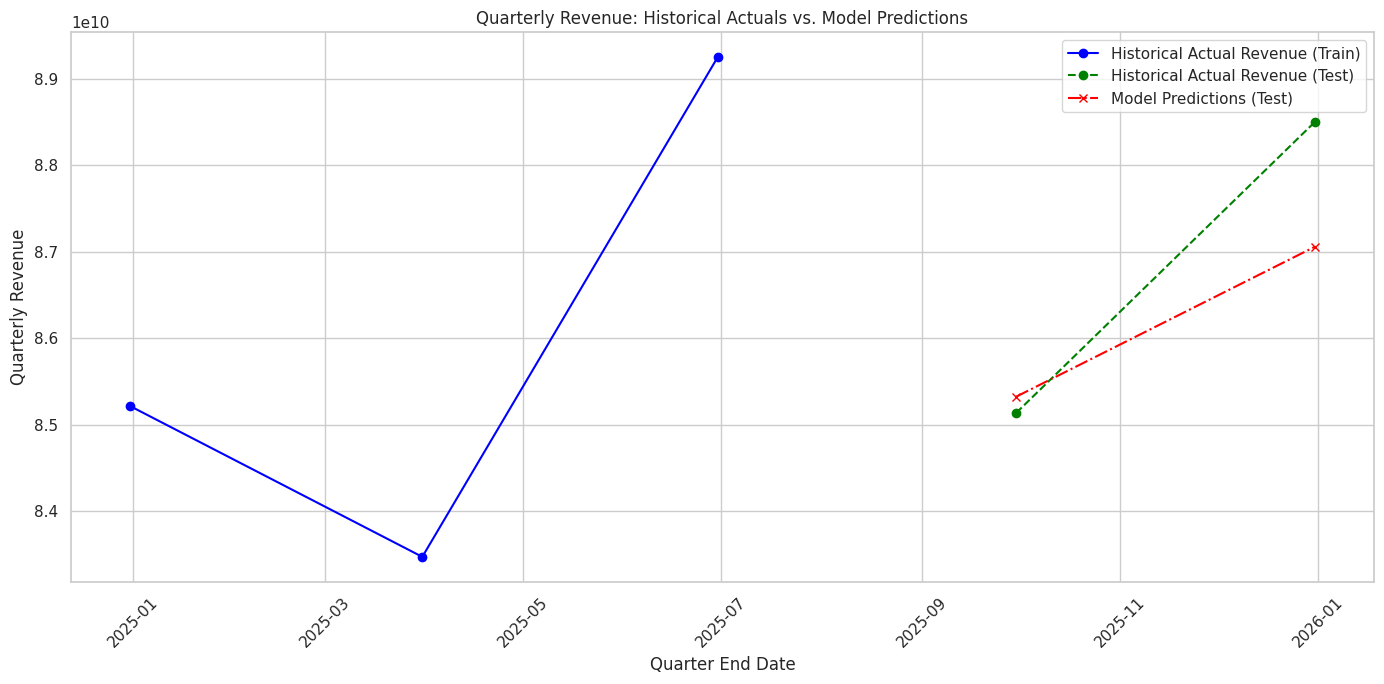

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 7))

# Plot historical actuals (training + testing data)
plt.plot(y_train.index, y_train, label='Historical Actual Revenue (Train)', color='blue', marker='o', linestyle='-')
plt.plot(y_test.index, y_test, label='Historical Actual Revenue (Test)', color='green', marker='o', linestyle='--')

# Plot model predictions for the test set
# Ensure the predictions align with the test set index
model_predictions_series = pd.Series(model_predictions, index=y_test.index)
plt.plot(model_predictions_series.index, model_predictions_series, label='Model Predictions (Test)', color='red', marker='x', linestyle='-.')

plt.title('Quarterly Revenue: Historical Actuals vs. Model Predictions')
plt.xlabel('Quarter End Date')
plt.ylabel('Quarterly Revenue')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
last_known_revenue = y_test.iloc[-1] if not y_test.empty else 8.5e10 # Use last test actual or a default

# Use the model's prediction for the last quarter of the test set as the predicted revenue
predicted_revenue = model_predictions[-1] # Assuming model_predictions corresponds to y_test
predicted_revenue_cr = predicted_revenue / 1e7 # Convert to Crores for display

# Placeholder for Street Expectation (this would typically be external analyst consensus data)
# For demonstration, let's assume street expects 3% growth over the last known ACTUAL revenue.
street_expectation = last_known_revenue * 1.03
street_expectation_cr = street_expectation / 1e7 # Convert to Crores for display

# Decision Logic and detailed explanation
narrative_summary = "--- Earnings Decision Summary ---\n\n"
narrative_summary += f"Latest Known Actual Revenue: ₹{last_known_revenue / 1e7:,.0f} Cr\n"
narrative_summary += f"Predicted Revenue (Model Forecast): ₹{predicted_revenue_cr:,.0f} Cr\n"
narrative_summary += f"Street Expectation (Analyst Consensus, hypothetical): ₹{street_expectation_cr:,.0f} Cr\n\n"

# Extract relevant features for the last predicted quarter and previous quarter for trend analysis
# We use X_test_imputed as it contains the processed features.
last_quarter_features = X_test_imputed.iloc[-1]
prev_quarter_features = X_test_imputed.iloc[-2] # For comparison with the immediately preceding quarter

crude_oil_curr = last_quarter_features['Crude_Oil_Price']
crude_oil_prev = prev_quarter_features['Crude_Oil_Price']
chem_ppi_curr = last_quarter_features['Chem_PPI_Proxy']
chem_ppi_prev = prev_quarter_features['Chem_PPI_Proxy']
is_festive_curr = last_quarter_features['Is_Festive']

qoq_revenue_growth_curr = master_df['QoQ_Revenue_Growth'].iloc[-1]
quarterly_opm_curr = master_df['Quarterly OPM'].iloc[-1]
margin_compression_qoq = last_quarter_features['Margin_Compression_QoQ']
margin_below_rolling_avg = last_quarter_features['Margin_Below_Rolling_Avg']

# Prepare a description of current quarter conditions based on key features
condition_statements = []

# Crude Oil Trend
if crude_oil_curr < crude_oil_prev:
    condition_statements.append(f"Crude Oil Prices: Decreasing ({crude_oil_prev:.2f} -> {crude_oil_curr:.2f})")
elif crude_oil_curr > crude_oil_prev:
    condition_statements.append(f"Crude Oil Prices: Increasing ({crude_oil_prev:.2f} -> {crude_oil_curr:.2f})")
else:
    condition_statements.append(f"Crude Oil Prices: Stable ({crude_oil_curr:.2f})")

# Chemical PPI Trend (Raw Material Proxy)
if chem_ppi_curr < chem_ppi_prev:
    condition_statements.append(f"Chemical PPI (Raw Material Proxy): Easing ({chem_ppi_prev:.2f} -> {chem_ppi_curr:.2f})")
elif chem_ppi_curr > chem_ppi_prev:
    condition_statements.append(f"Chemical PPI (Raw Material Proxy): Increasing ({chem_ppi_prev:.2f} -> {chem_ppi_curr:.2f})")
else:
    condition_statements.append(f"Chemical PPI (Raw Material Proxy): Stable ({chem_ppi_curr:.2f})")

# Festive Season Demand
if is_festive_curr == 1:
    condition_statements.append("Festive Season: Active (Potential for strong demand)")
else:
    condition_statements.append("Festive Season: Not in period (Neutral demand indicator)")

# QoQ Revenue Growth
condition_statements.append(f"QoQ Revenue Growth: {qoq_revenue_growth_curr:.2f}%")

# Quarterly OPM
condition_statements.append(f"Quarterly OPM: {quarterly_opm_curr:.2f}%")

# Margin Compression Signals
if margin_compression_qoq == 1:
    condition_statements.append("Margin Compression: QoQ OPM decreased.")
if margin_below_rolling_avg == 1:
    condition_statements.append("Margin Compression: OPM below its rolling average.")

conditions_summary_text = ""
if condition_statements:
    conditions_summary_text = "\nMarket Conditions:\n  - " + "\n  - ".join(condition_statements)

# Generate the main signal
signal_message = ""
signal_type = "Neutral"

if predicted_revenue > street_expectation * 1.01: # Allowing for a small margin (1%) for 'beat'
    signal_message = f"Asian Paints is likely to BEAT earnings estimates."
    signal_type = "Bullish"
elif predicted_revenue < street_expectation * 0.99: # Allowing for a small margin for 'miss'
    signal_message = f"Asian Paints is likely to MISS earnings estimates."
    signal_type = "Bearish"
else:
    signal_message = f"Asian Paints earnings are expected to be IN LINE with expectations."

narrative_summary += f"**Prediction**: {signal_message}\n"
narrative_summary += conditions_summary_text
narrative_summary += f"\n\n**Overall Signal**: {signal_type} signal"

print(narrative_summary)

--- Earnings Decision Summary ---

Latest Known Actual Revenue: ₹8,850 Cr
Predicted Revenue (Model Forecast): ₹8,706 Cr
Street Expectation (Analyst Consensus, hypothetical): ₹9,115 Cr

**Prediction**: Asian Paints is likely to MISS earnings estimates.

Market Conditions:
  - Crude Oil Prices: Decreasing (68.12 -> 63.09)
  - Chemical PPI (Raw Material Proxy): Easing (350.62 -> 348.23)
  - Festive Season: Active (Potential for strong demand)
  - QoQ Revenue Growth: 3.95%
  - Quarterly OPM: 16.59%

**Overall Signal**: Bearish signal
